In [ ]:

"""
改进内容：
1. 区分 CAPEX/OPEX 成本并年化折现；
2. SOC 改为周期性约束（SOC=10% → 10%）；
3. 增加充放电切换间隔15min约束；
4. 增加充放电连续性约束（至少2个点）；
5. 保持15分钟分辨率；
"""

import numpy as np
import pandas as pd
from pyscipopt import Model, quicksum


def optimize_storage(
    price_curve,
    load_curve,
    transformer_rating,
    time_interval_hours=0.25,  # 改为15分钟粒度
    charge_efficiency=0.95,
    discharge_efficiency=0.95,
    min_depth_of_discharge=0.1,
    min_power_ratio=0.0,
    max_cycles_per_year=650,
    min_utilization=0.75,
    # ========== 新增 CAPEX/OPEX 参数 ==========
    capex_per_kwh=2500,       # 投资成本 元/kWh
    opex_per_cycle_kwh=0.1,   # 循环衰减成本 元/kWh
    battery_life_years=10,    # 寿命期 年
    discount_rate=0.08,       # 折现率
    c_rate=0.5,
):
    """
    优化储能系统的额定功率和容量
    """

    total_periods = len(price_curve)
    hours_per_year = 365 * 24
    total_hours = total_periods * time_interval_hours
    max_cycles = int(max_cycles_per_year * max(total_hours / hours_per_year, 1.0))

    model = Model("Storage Optimization V2")
    model.setParam("limits/time", 200)
    model.setParam("numerics/feastol", 1e-4)
    model.setParam("numerics/dualfeastol", 1e-4)

    P_ch, P_dis, E, u_ch, u_dis = {}, {}, {}, {}, {}

    for t in range(total_periods):
        P_ch[t] = model.addVar(lb=0, name=f"P_ch_{t}")
        P_dis[t] = model.addVar(lb=0, name=f"P_dis_{t}")
        E[t] = model.addVar(lb=0, name=f"E_{t}")
        u_ch[t] = model.addVar(vtype="B", name=f"u_ch_{t}")
        u_dis[t] = model.addVar(vtype="B", name=f"u_dis_{t}")

    Cap_rated = model.addVar(lb=0, name="Cap_rated")
    P_rated = Cap_rated * c_rate

    # ========== 约束 ==========
    for t in range(total_periods):
        model.addCons(P_ch[t] <= P_rated)
        model.addCons(P_dis[t] <= P_rated)
        model.addCons(u_ch[t] + u_dis[t] <= 1)

        if min_power_ratio > 0:
            model.addCons(P_ch[t] >= P_rated * min_power_ratio * u_ch[t])
            model.addCons(P_dis[t] >= P_rated * min_power_ratio * u_dis[t])
        else:
            model.addCons(P_ch[t] <= P_rated * u_ch[t])
            model.addCons(P_dis[t] <= P_rated * u_dis[t])

        model.addCons(P_dis[t] <= load_curve[t])
        model.addCons(load_curve[t] + P_ch[t] <= transformer_rating)

        # SOC周期性约束：SOC从10%到10%
        if t == 0:
            model.addCons(E[t] == Cap_rated * 0.1)
        else:
            model.addCons(
                E[t]
                == E[t - 1]
                + P_ch[t] * charge_efficiency * time_interval_hours
                - P_dis[t] * time_interval_hours / discharge_efficiency
            )

        model.addCons(E[t] <= Cap_rated)
        model.addCons(E[t] >= Cap_rated * min_depth_of_discharge)

    # 结束时SOC = 初始SOC = 10%
    model.addCons(E[total_periods - 1] == Cap_rated * 0.1)

    # 新增：充放电切换间隔约束（禁止15分钟内反向）
    for t in range(1, total_periods):
        model.addCons(u_ch[t] + u_dis[t - 1] <= 1)
        model.addCons(u_dis[t] + u_ch[t - 1] <= 1)

    # 新增：充放电至少连续两个点
    for t in range(total_periods - 2):
        model.addCons(u_ch[t + 1] >= u_ch[t] - u_ch[t + 2])
        model.addCons(u_dis[t + 1] >= u_dis[t] - u_dis[t + 2])

    # 总放电量约束
    total_discharge = quicksum(
        P_dis[t] * time_interval_hours for t in range(total_periods)
    )
    model.addCons(total_discharge >= max_cycles * Cap_rated * min_utilization)
    model.addCons(total_discharge <= max_cycles * Cap_rated)

    # ========== 目标函数 ==========
    weighted_prices = [
        price_curve[t] * time_interval_hours for t in range(total_periods)
    ]
    discharge_revenue = quicksum(
        weighted_prices[t] * P_dis[t] for t in range(total_periods)
    )
    charge_cost = quicksum(weighted_prices[t] * P_ch[t] for t in range(total_periods))

    # 年化投资成本 + 循环OPEX成本
    annualized_capex = (
        capex_per_kwh
        * Cap_rated
        * (discount_rate * (1 + discount_rate) ** battery_life_years)
        / ((1 + discount_rate) ** battery_life_years - 1)
    )
    storage_cost = (
        quicksum(P_dis[t] * time_interval_hours * opex_per_cycle_kwh for t in range(total_periods))
        + annualized_capex
    )

    model.setObjective(discharge_revenue - charge_cost - storage_cost, "maximize")

    # ========== 求解 ==========
    model.optimize()
    status = model.getStatus()
    print(f"求解状态: {status}")

    income = model.getObjVal()
    optimal_power = model.getVal(P_rated)
    optimal_capacity = model.getVal(Cap_rated)
    total_discharge_value = sum(
        model.getVal(P_dis[t]) * time_interval_hours for t in range(total_periods)
    )
    actual_utilization = (
        total_discharge_value / (max_cycles * optimal_capacity)
        if optimal_capacity > 0
        else 0
    )

    charge_schedule = [model.getVal(P_ch[t]) for t in range(total_periods)]
    discharge_schedule = [model.getVal(P_dis[t]) for t in range(total_periods)]
    energy_level = [model.getVal(E[t]) for t in range(total_periods)]

    print("\n-------------充放电统计------------------")
    charge_kwh = sum(charge_schedule) * time_interval_hours
    discharge_kwh = sum(discharge_schedule) * time_interval_hours
    print(f"总充电电量: {charge_kwh/1000:.2f} MWh")
    print(f"总放电电量: {discharge_kwh/1000:.2f} MWh")
    print(f"充放电效率: {discharge_kwh/charge_kwh*100:.2f}%" if charge_kwh > 0 else "无充电")

    return (
        income,
        optimal_power,
        optimal_capacity,
        actual_utilization,
        charge_schedule,
        discharge_schedule,
        energy_level,
        charge_kwh,
        discharge_kwh,
    )


# ========== 主程序入口（保持原逻辑） ==========
if __name__ == "__main__":
    price_df = pd.read_csv("merged_df.csv", parse_dates=["日期时间"])
    load_df = pd.read_excel("兴达_processed.xlsx", skiprows=96, names=["time", "load"], parse_dates=["time"])

    # 保持15分钟粒度，不重采样
    filter_mask = (
        (load_df["time"] >= "2025-02-19 00:00:00") & (load_df["time"] <= "2025-02-19 23:45:00")
    ) | (
        (load_df["time"] >= "2025-08-16 00:00:00") & (load_df["time"] <= "2025-08-16 23:45:00")
    )
    load_df = load_df[~filter_mask]
    load_df["period"] = list(range(96)) * (len(load_df) // 96)
    load_curve = load_df.groupby("period")["load"].mean()
    price_df["Load"] = np.array(load_curve.tolist() * (len(price_df) // 96))

    price_curve = price_df["电能价格"].values / 1000  # 元/kWh
    load_curve = price_df["Load"].values
    transformer_rating = int(load_curve.max() * 2.0)
    storage_cost_per_kwh = 0.65
    time_interval_hours = 0.25  # 保持15分钟

    for min_utilization in [0.5, 0.6, 0.7]:
        for c_rate in [0.25, 0.5, 1.0]:
            print("\n-------------限定条件------------------")
            print(f"变压器容量: {transformer_rating} KVA")
            print(f"最小利用率: {min_utilization*100:.1f}%")
            print(f"C倍率: {c_rate}C")

            (
                income,
                optimal_power,
                optimal_capacity,
                actual_utilization,
                charge_schedule,
                discharge_schedule,
                energy_level,
                charge_kwh,
                discharge_kwh,
            ) = optimize_storage(
                price_curve,
                load_curve,
                transformer_rating,
                time_interval_hours=time_interval_hours,
                charge_efficiency=0.95,
                discharge_efficiency=0.95,
                min_depth_of_discharge=0.1,
                min_power_ratio=0.1,
                max_cycles_per_year=650,
                min_utilization=min_utilization,
                capex_per_kwh=2500,
                opex_per_cycle_kwh=0.1,
                battery_life_years=10,
                discount_rate=0.08,
                c_rate=c_rate,
            )

            print("\n-------------最终结果------------------")
            print(f"最优储能额定功率: {optimal_power/1000:.2f} MW")
            print(f"最优储能额定容量: {optimal_capacity/1000:.2f} MWh")
            print(f"实际利用率: {actual_utilization:.2%}")
            print(f"充电电量: {charge_kwh/1000:.2f} MWh")
            print(f"放电电量: {discharge_kwh/1000:.2f} MWh")
            print(f"套利净收益（含CAPEX/OPEX年化）: {income/10000:.2f} 万元")



-------------限定条件------------------
变压器容量: 90211 KVA
最小利用率: 50.0%
C倍率: 0.25C


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

In [7]:
def clean_and_merge_time(df, date_col="日期", hour_col="小时", value_col="电量", zero_threshold=1):
    df = df.copy()

    # -------- Step 1. 拼接时间列 --------
    df["日期_clean"] = pd.to_datetime(df[date_col].astype(str).str.split(" ").str[0])
    df["小时_clean"] = df[hour_col].astype(str).str.strip()
    mask_24 = df["小时_clean"].str.startswith("24")
    df.loc[mask_24, "日期_clean"] += timedelta(days=1)
    df.loc[mask_24, "小时_clean"] = "00:00"
    df["时间"] = pd.to_datetime(df["日期_clean"].astype(str) + " " + df["小时_clean"])
    df = df.sort_values("时间").reset_index(drop=True)

    # 初始化
    df["电量_修正"] = df[value_col]
    df["修正标识"] = "正常"

    # -------- Step 2. 0值检测 --------
    zero_mask = (df[value_col] <= zero_threshold) | (df[value_col].isna())
    zero_indices = df[zero_mask].index

    # 标记修正类型
    df.loc[zero_indices, "修正标识"] = "0值待修正"

    # -------- Step 3. 阶跃检测 --------
    diffs = df[value_col].diff().abs()
    threshold = diffs.mean() + 3 * diffs.std()
    jump_mask = diffs > threshold
    jump_indices = df[jump_mask].index
    df.loc[jump_indices, "修正标识"] = "阶跃待修正"

    # -------- Step 4. 线性平滑修复 --------
    # 将待修正的点设置为 NaN，然后用时间为索引进行线性插值
    df["电量_修正"] = df[value_col]
    df.loc[df["修正标识"].isin(["0值待修正", "阶跃待修正"]), "电量_修正"] = None

    # 按时间插值（线性平滑）
    df["电量_修正"] = (
        df.set_index("时间")["电量_修正"]
        .interpolate(method="time", limit_direction="both")
        .reset_index(drop=True)
    )

    # -------- Step 5. 对无法插值的点，用前一天同刻值补全 --------
    still_nan = df["电量_修正"].isna()
    for i in df[still_nan].index:
        t_prev_day = df.loc[i, "时间"] - timedelta(days=1)
        prev_day_val = df.loc[df["时间"] == t_prev_day, value_col]
        if not prev_day_val.empty:
            df.loc[i, "电量_修正"] = prev_day_val.values[0]
            df.loc[i, "修正标识"] = "前日值补全"
        else:
            df.loc[i, "电量_修正"] = df[value_col].mean()
            df.loc[i, "修正标识"] = "均值补全"

    # 更新标识（最终修正类型）
    df.loc[df["修正标识"] == "0值待修正", "修正标识"] = "0值修正(线性)"
    df.loc[df["修正标识"] == "阶跃待修正", "修正标识"] = "阶跃修正(线性)"

    return df



def resample_to_15min(df, time_col="Time", cols=None):
    """
    将 1 小时分辨率的数据线性插值为 15 分钟，
    自动处理重复时间，避免 pandas 报错。
    """
    df = df.copy()

    # 1) 统一时间格式
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")

    # 2) 删除非法时间
    df = df.dropna(subset=[time_col])

    # 3) 按时间排序
    df = df.sort_values(time_col)

    # 4) 删除重复时间（保留最后一条）
    df = df.drop_duplicates(subset=[time_col], keep="last")

    # 5) 设为时间索引
    df = df.set_index(time_col)

    # 选择需要插值的列
    if cols is None:
        cols = [c for c in df.columns if df[c].dtype != "O"]

    # 6) 插值为 15 min
    df_resampled = df[cols].resample("15min").interpolate("linear")

    # 7) 恢复 Time 列
    df_resampled = df_resampled.reset_index()

    return df_resampled

In [8]:
df_load = pd.read_excel('D:/内蒙项目/多蒙德2024.xlsx')
df_load = clean_and_merge_time(df_load)
df_load = df_load[["时间", "电量_修正"]]
df_load = df_load.rename(columns={"时间":"Time","电量_修正": "Load"})
# df_load = resample_to_15min(df_load)
# df_price = pd.read_csv('D:/内蒙项目/resources/node-price-by-node4/内蒙_天皮山站 内蒙_天皮山站_220kV_1M__合并3.csv')
# df_price = df_price.rename(columns={"datetime":"Time","Node pricing(yuan/MWh)": "节点电价(元/MWh)","Electricity price(yuan/MWh)": "电能价格(元/MWh)","Blocking prices(yuan/MWh)": "阻塞价格(元/MWh)"})
# df_price["Time"] = pd.to_datetime(df_price["Time"])
df_price = pd.read_csv('D:/PythonProject/ba_eva/merged_df.csv')
df_price["日期时间"] = pd.to_datetime(df_price["日期时间"])
# print(df_price)
df_merger = pd.merge(df_load, df_price, left_on="Time",right_on="日期时间", how="left")


In [34]:
import seaborn as sns
from matplotlib import font_manager
font_path = r"C:\Windows\Fonts\simsun.ttc"
font = font_manager.FontProperties(fname=font_path)

plt.rcParams["font.family"] = font.get_name()
plt.rcParams["axes.unicode_minus"] = False


class StorageFeasibilityAnalyzer:

    def __init__(
        self,
        load_col="负荷",
        price_col="电价",
        time_col="时间",
        transformer_kva=80000,
        power_factor=0.95,
        power_unit="MW",
        price_unit="CNY_per_MWh",
    ):
        self.load_col = load_col
        self.price_col = price_col
        self.time_col = time_col
        self.transformer_kva = transformer_kva
        self.power_factor = power_factor
        self.power_unit = power_unit
        self.price_unit = price_unit

    # =====================================================
    # 单位归一化模块
    # =====================================================
    def normalize_units(self, df):
        df = df.copy()

        # —— 功率单位处理 ——
        if self.power_unit.lower() == "kw":
            pass
        elif self.power_unit.lower() == "mw":
            df[self.load_col] = df[self.load_col] * 1000
        elif self.power_unit.lower() == "w":
            df[self.load_col] = df[self.load_col] / 1000
        elif self.power_unit.lower() == "gw":
            df[self.load_col] = df[self.load_col] * 1_000_000
        else:
            raise ValueError(f"不支持的 power_unit: {self.power_unit}")

        # —— 电价单位处理 ——
        u = self.price_unit.lower()
        if u in ["cny_per_kwh", "yuan_kwh", "元_kwh"]:
            pass
        elif u in ["cny_per_mwh", "yuan_mwh", "元_mwh"]:
            df[self.price_col] = df[self.price_col] / 1000
        else:
            raise ValueError(f"不支持的 price_unit: {self.price_unit}")

        df[self.time_col] = pd.to_datetime(df[self.time_col])
        df = df.sort_values(self.time_col).reset_index(drop=True)

        return df

    # =====================================================
    # 一、基础分析：电价 + 负荷 + 变压器
    # =====================================================
    def analyze_basic(self, df):
        df = df.copy()

        dt = (df[self.time_col].iloc[1] - df[self.time_col].iloc[0]).total_seconds() / 3600
        total_hours = len(df) * dt

        price = df[self.price_col]
        load = df[self.load_col]

        # 电价指标
        q30, q70 = price.quantile([0.3, 0.7])
        high_mask = price >= q70
        low_mask = price <= q30

        price_info = {
            "价格均值": float(price.mean()),
            "高价均值(P≥P70)": float(price[high_mask].mean()),
            "低价均值(P≤P30)": float(price[low_mask].mean()),
            "日内价差": float(price[high_mask].mean() - price[low_mask].mean()),
            "高价小时/天": float(high_mask.sum() * dt / (total_hours / 24)),
            "电价波动σ": float(price.std()),
        }

        # 负荷指标
        load_info = {
            "负荷最大值(kW)": float(load.max()),
            "负荷均值(kW)": float(load.mean()),
            "负荷最小值(kW)": float(load.min()),
            "峰谷比": float(load.max() / load.mean()),
        }

        # 变压器容量
        tr_pmax = self.transformer_kva * self.power_factor
        df["变压器剩余容量_kW"] = tr_pmax - df[self.load_col]

        spare = df["变压器剩余容量_kW"]
        spare_info = {
            "变压器容量(kVA)": self.transformer_kva,
            "等效有功上限(kW)": tr_pmax,
            "最小剩余(kW)": float(spare.min()),
            "中位剩余(kW)": float(spare.median()),
            "可充电窗口(h/天)": float((spare > 0).sum() * dt / (total_hours / 24)),
        }

        return price_info, load_info, spare_info, df

    # =====================================================
    # 二、匹配性分析（电价 × 负荷 × 变压器）
    # =====================================================
    def analyze_matching(self, df):
        p70 = df[self.price_col].quantile(0.7)
        p30 = df[self.price_col].quantile(0.3)

        high_mask = df[self.price_col] >= p70
        low_mask = df[self.price_col] <= p30

        # —— 高价是否对应高负荷 ——
        corr_high = (
            np.corrcoef(df.loc[high_mask, self.price_col], df.loc[high_mask, self.load_col])[0, 1]
            if high_mask.sum() > 5
            else 0
        )

        # —— 低价是否对应低负荷 ——
        corr_low = (
            np.corrcoef(df.loc[low_mask, self.price_col], df.loc[low_mask, self.load_col])[0, 1]
            if low_mask.sum() > 5
            else 0
        )

        # —— 低价时是否有余量充电 ——
        charge_feas = (df.loc[low_mask, "变压器剩余容量_kW"] > 0).mean()

        # —— 综合策略可执行性 ——
        df["可充标记"] = (df[self.price_col] <= p30) & \
                       (df[self.load_col] <= df[self.load_col].quantile(0.5)) & \
                       (df["变压器剩余容量_kW"] > 0)

        strategy_feas = df["可充标记"].mean()

        # 综合评分
        score = (
            max(0, corr_high) * 0.4 +
            max(0, -corr_low) * 0.2 +
            charge_feas * 0.2 +
            strategy_feas * 0.2
        )
        score = min(max(score, 0), 1)

        # 评分结论
        if score >= 0.75:
            comment = "🔋 匹配性高，储能策略可有效执行。"
        elif score >= 0.55:
            comment = "⚡ 匹配性中等，可部署储能但需优化策略。"
        elif score >= 0.35:
            comment = "⚠️ 匹配性偏弱，建议小容量高功率或策略优化。"
        else:
            comment = "⛔ 匹配性不足，不建议建设储能。"

        return {
            "高价-高负荷匹配度": corr_high,
            "低价-低负荷匹配度": corr_low,
            "低价可充电比例": charge_feas,
            "策略可执行比例": strategy_feas,
            "匹配性评分(0-1)": score,
            "结论": comment,
        }

    # =====================================================
    # 三、图形分析：电价、负荷、散点相关性等
    # =====================================================
    def plot_all(self, df):
        # 电价曲线
        plt.figure(figsize=(14, 6))
        plt.plot(df[self.time_col], df[self.price_col], label="电价 元/kWh")
        plt.title("电价曲线")
        plt.grid(True)
        plt.legend()
        plt.show()

        # 负荷曲线
        plt.figure(figsize=(14, 6))
        plt.plot(df[self.time_col], df[self.load_col], label="负荷 kW")
        plt.title("负荷曲线")
        plt.grid(True)
        plt.legend()
        plt.show()

        # 电价 vs 负荷 散点
        plt.figure(figsize=(7, 5))
        sns.scatterplot(x=df[self.price_col], y=df[self.load_col], alpha=0.5)
        plt.title("电价 vs 负荷 散点图")
        plt.xlabel("电价 (元/kWh)")
        plt.ylabel("负荷 (kW)")
        plt.grid(True)
        plt.show()

        # 分布图
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        sns.histplot(df[self.price_col], kde=True)
        plt.title("电价分布")

        plt.subplot(1, 2, 2)
        sns.histplot(df[self.load_col], kde=True)
        plt.title("负荷分布")
        plt.show()


# END CLASS


In [10]:
print(df_merger.columns)

Index(['Time', 'Load', '日期时间', '节点电价', '电能价格', '阻塞价格', '补全标识'], dtype='object')


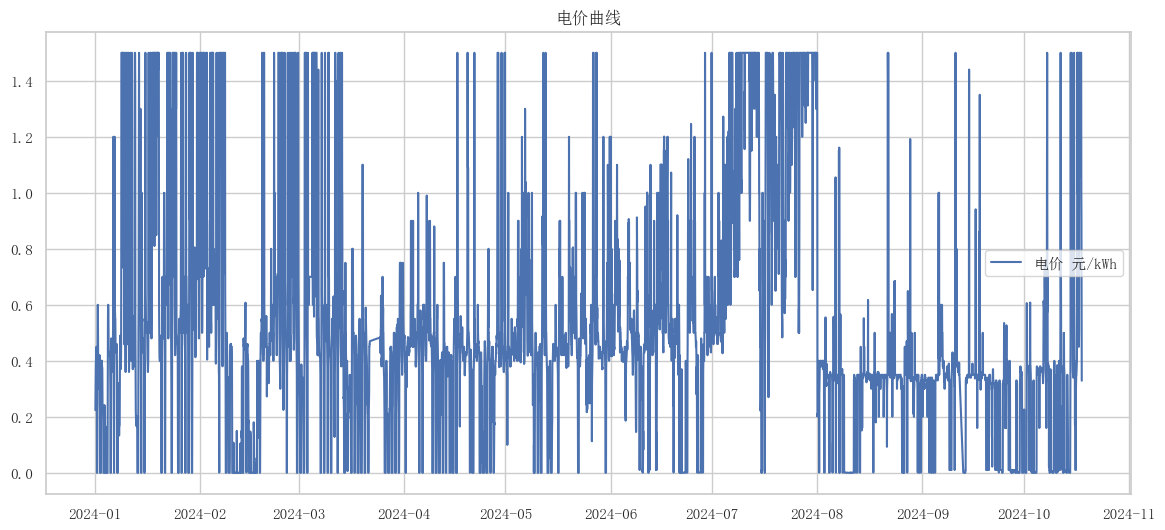

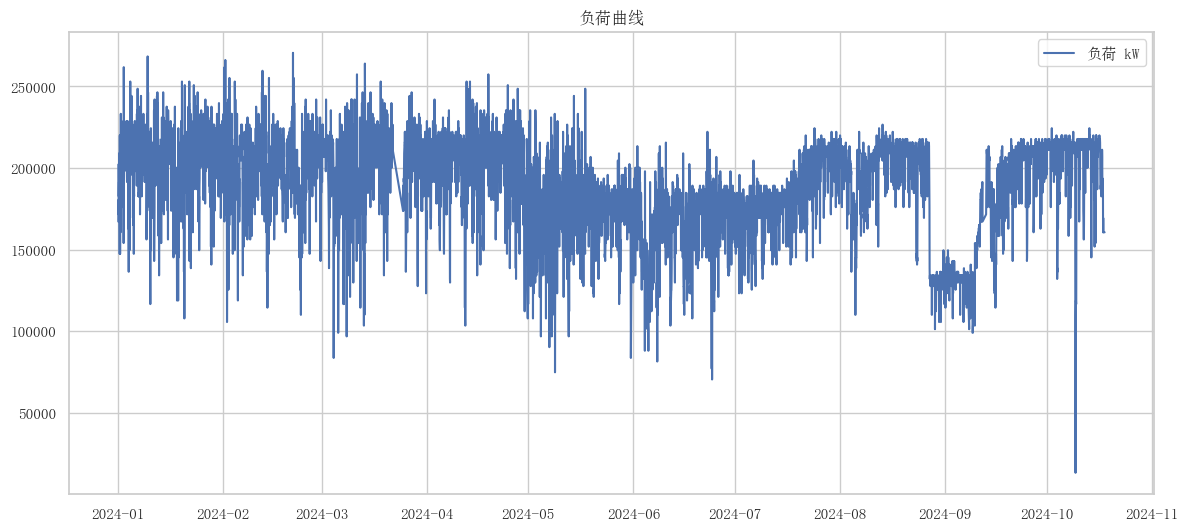

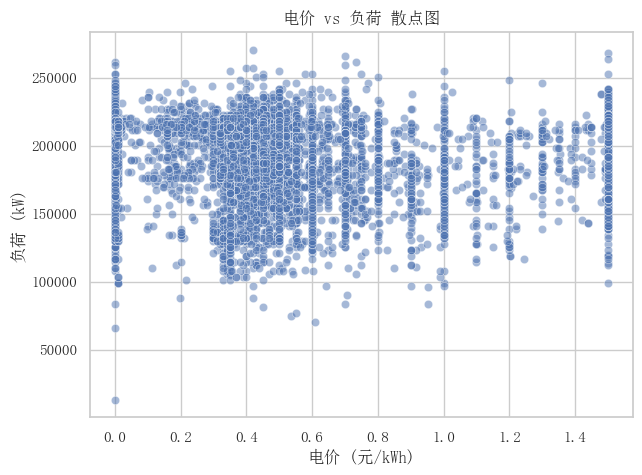

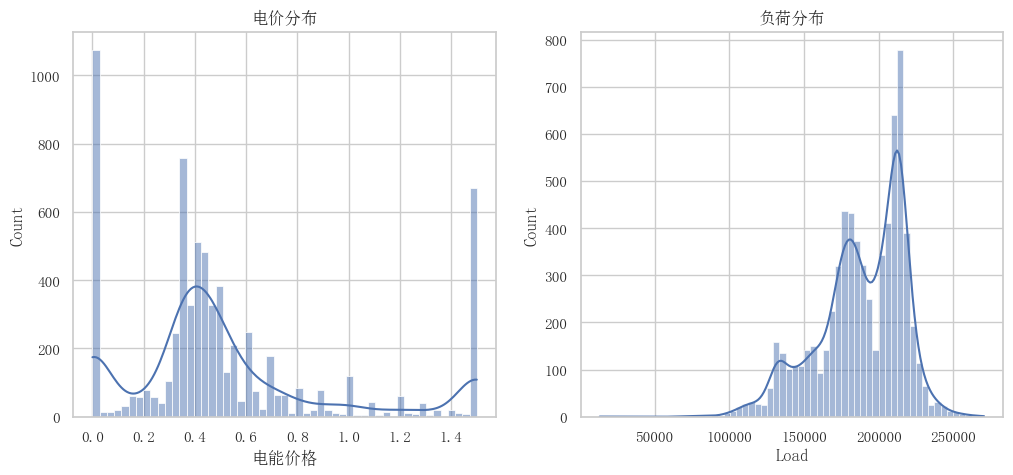


=== 电价分析 ===
{'价格均值': 0.5259625123939043, '高价均值(P≥P70)': 1.0191247366605336, '低价均值(P≤P30)': 0.1654171153052805, '日内价差': 0.8537076213552531, '高价小时/天': 7.548611111111111, '电价波动σ': 0.4230035653256526}

=== 负荷分析 ===
{'负荷最大值(kW)': 270600.0, '负荷均值(kW)': 188413.32465277778, '负荷最小值(kW)': 13200.0, '峰谷比': 1.436204156466545}

=== 变压器分析 ===
{'变压器容量(kVA)': 250000, '等效有功上限(kW)': 237500.0, '最小剩余(kW)': -33100.0, '中位剩余(kW)': 46100.0, '可充电窗口(h/天)': 23.6875}

=== 匹配性分析 ===
{'高价-高负荷匹配度': np.float64(0.1071760271730815), '低价-低负荷匹配度': np.float64(-0.18239152136231737), '低价可充电比例': np.float64(0.9884488448844885), '策略可执行比例': np.float64(0.14322916666666666), '匹配性评分(0-1)': np.float64(0.3056843174519271), '结论': '⛔ 匹配性不足，不建议建设储能。'}


In [35]:
analyzer = StorageFeasibilityAnalyzer(
    load_col="Load",
    price_col="电能价格",
    time_col="Time",
    transformer_kva=250000,      # 比如 90 MVA
    power_factor=0.95,
    power_unit="MW",            # 你的负荷是 MW
    price_unit="CNY_per_MWh"    # 你的电价是 元/MWh
)

# 1）单位转换
df_std = analyzer.normalize_units(df_merger)

# 2）基础分析
price_info, load_info, spare_info, df2 = analyzer.analyze_basic(df_std)

# 3）三要素匹配性分析
match = analyzer.analyze_matching(df2)

# 4）图形展示
analyzer.plot_all(df2)

# 打印结果
print("\n=== 电价分析 ===")
print(price_info)

print("\n=== 负荷分析 ===")
print(load_info)

print("\n=== 变压器分析 ===")
print(spare_info)

print("\n=== 匹配性分析 ===")
print(match)

In [36]:
class StorageFeasibilityAnalyzer_V5:

    def __init__(
        self,
        load_col="负荷",
        price_col="电价",
        time_col="时间",
        transformer_kva=80000,
        power_factor=0.95,
        power_unit="MW",
        price_unit="CNY_per_MWh",
    ):
        self.load_col = load_col
        self.price_col = price_col
        self.time_col = time_col
        self.transformer_kva = transformer_kva
        self.power_factor = power_factor
        self.power_unit = power_unit
        self.price_unit = price_unit

    # =====================================================
    # 0) 单位标准化
    # =====================================================
    def normalize_units(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        # 功率单位转换
        pu = self.power_unit.lower()
        if pu == "kw":
            pass
        elif pu == "mw":
            df[self.load_col] = df[self.load_col] * 1000
        elif pu == "gw":
            df[self.load_col] = df[self.load_col] * 1_000_000
        elif pu == "w":
            df[self.load_col] = df[self.load_col] / 1000
        else:
            raise ValueError(f"不支持 power_unit: {self.power_unit}")

        # 电价单位转换
        u = self.price_unit.lower()
        if u in ["cny_per_kwh", "yuan_kwh", "元_kwh"]:
            pass
        elif u in ["cny_per_mwh", "yuan_mwh", "元_mwh"]:
            df[self.price_col] = df[self.price_col] / 1000
        else:
            raise ValueError(f"不支持 price_unit: {self.price_unit}")

        df[self.time_col] = pd.to_datetime(df[self.time_col])
        df = df.sort_values(self.time_col).reset_index(drop=True)
        return df

    # =====================================================
    # 1) 仅电价分析
    # =====================================================
    def analyze_price_only(self, df_price):
        df = df_price.copy()
        df[self.time_col] = pd.to_datetime(df[self.time_col])
        df = df.sort_values(self.time_col)

        price = df[self.price_col]
        q30, q70 = price.quantile([0.3, 0.7])

        return {
            "价格均值": float(price.mean()),
            "高价均值(P>=70%)": float(price[price >= q70].mean()),
            "低价均值(P<=30%)": float(price[price <= q30].mean()),
            "日内价差": float(price[price >= q70].mean() - price[price <= q30].mean()),
            "电价波动σ": float(price.std()),
            "样本数量": len(df),
            "起止时间": (df[self.time_col].min(), df[self.time_col].max())
        }

    # =====================================================
    # 2) 仅负荷分析
    # =====================================================
    def analyze_load_only(self, df_load):
        df = df_load.copy()
        df[self.time_col] = pd.to_datetime(df[self.time_col])
        df = df.sort_values(self.time_col)

        load = df[self.load_col]

        return {
            "负荷最大值(kW)": float(load.max()),
            "负荷均值(kW)": float(load.mean()),
            "负荷最小值(kW)": float(load.min()),
            "峰谷比": float(load.max() / load.mean()),
            "样本数量": len(df),
            "起止时间": (df[self.time_col].min(), df[self.time_col].max())
        }

    # =====================================================
    # 3) 电价 + 负荷自动对齐（支持多种方式）
    # =====================================================
    def align_price_load(self, df_price, df_load, mode="inner"):
        df_price = df_price.copy()
        df_load = df_load.copy()

        df_price[self.time_col] = pd.to_datetime(df_price[self.time_col])
        df_load[self.time_col] = pd.to_datetime(df_load[self.time_col])

        if mode == "inner":
            df = pd.merge(df_price, df_load, on=self.time_col, how="inner")
        elif mode == "left":
            df = pd.merge(df_load, df_price, on=self.time_col, how="left")
        elif mode == "right":
            df = pd.merge(df_price, df_load, on=self.time_col, how="right")
        elif mode == "nearest":
            df = pd.merge_asof(
                df_load.sort_values(self.time_col),
                df_price.sort_values(self.time_col),
                on=self.time_col,
                direction="nearest",
                tolerance=pd.Timedelta("30min"),
            )
        else:
            raise ValueError("mode 必须为 inner / left / right / nearest")

        df = df.dropna().reset_index(drop=True)
        return df

    # =====================================================
    # 4) 综合分析入口（自动对齐）
    # =====================================================
    def analyze_combined(self, df_price, df_load, mode="inner"):
        df = self.align_price_load(df_price, df_load, mode)
        df = self.normalize_units(df)

        price_info, load_info, spare_info, df2 = self.analyze_basic(df)
        match = self.analyze_matching(df2)

        return {
            "电价分析": price_info,
            "负荷分析": load_info,
            "变压器分析": spare_info,
            "匹配性分析": match,
            "数据": df2
        }

    # =====================================================
    # 5) 基础分析（原版）
    # =====================================================
    def analyze_basic(self, df: pd.DataFrame):
        df = df.copy()

        dt = (df[self.time_col].iloc[1] - df[self.time_col].iloc[0]).total_seconds() / 3600
        total_hours = len(df) * dt

        price = df[self.price_col]
        load = df[self.load_col]

        q30, q70 = price.quantile([0.3, 0.7])
        high_mask = price >= q70
        low_mask = price <= q30

        price_info = {
            "价格均值": float(price.mean()),
            "高价均值(P>=70%)": float(price[high_mask].mean()),
            "低价均值(P<=30%)": float(price[low_mask].mean()),
            "日内价差": float(price[high_mask].mean() - price[low_mask].mean()),
            "电价波动σ": float(price.std()),
        }

        load_info = {
            "负荷最大值(kW)": float(load.max()),
            "负荷均值(kW)": float(load.mean()),
            "负荷最小值(kW)": float(load.min()),
            "峰谷比": float(load.max() / load.mean()),
        }

        tr_pmax = self.transformer_kva * self.power_factor
        df["变压器剩余容量_kW"] = tr_pmax - df[self.load_col]

        spare_info = {
            "变压器额定(kVA)": self.transformer_kva,
            "有功上限(kW)": tr_pmax,
            "最小剩余(kW)": float(df["变压器剩余容量_kW"].min()),
            "中位剩余(kW)": float(df["变压器剩余容量_kW"].median()),
        }

        return price_info, load_info, spare_info, df

    # =====================================================
    # 6) 扩展分析（月度 + 偏度峰度）
    # =====================================================
    def analyze_basic_extended(self, df: pd.DataFrame):
        df = df.copy()
        price = df[self.price_col]
        load = df[self.load_col]

        ext = {
            "电价偏度": float(price.skew()),
            "电价峰度": float(price.kurtosis()),
            "负荷偏度": float(load.skew()),
            "负荷峰度": float(load.kurtosis()),
            "电价-负荷相关系数": float(np.corrcoef(price, load)[0, 1]),
        }

        df["month"] = df[self.time_col].dt.month
        monthly = df.groupby("month").agg(
            月均价=(self.price_col, "mean"),
            月均负荷=(self.load_col, "mean"),
            月最大负荷=(self.load_col, "max"),
        )
        return ext, monthly

    # =====================================================
    # 7) 匹配性分析
    # =====================================================
    def analyze_matching(self, df: pd.DataFrame):
        df = df.copy()

        p70 = df[self.price_col].quantile(0.7)
        p30 = df[self.price_col].quantile(0.3)

        high = df[self.price_col] >= p70
        low = df[self.price_col] <= p30

        corr_high = float(
            np.corrcoef(
                df.loc[high, self.price_col], df.loc[high, self.load_col]
            )[0, 1]
        ) if high.sum() > 3 else 0

        corr_low = float(
            np.corrcoef(
                df.loc[low, self.price_col], df.loc[low, self.load_col]
            )[0, 1]
        ) if low.sum() > 3 else 0

        charge_feas = (df.loc[low, "变压器剩余容量_kW"] > 0).mean()

        score = (
            max(0, corr_high) * 0.4 +
            max(0, -corr_low) * 0.2 +
            charge_feas * 0.4
        )
        score = float(min(max(score, 0), 1))

        if score >= 0.75:
            comment = "🔋 匹配性高，适合中/大容量中功率"
        elif score >= 0.55:
            comment = "⚡ 中等匹配，建议中等容量"
        elif score >= 0.35:
            comment = "⚠️ 匹配性不足，适合小容量高功率"
        else:
            comment = "⛔ 不建议建设储能"

        return {
            "高价-高负荷匹配度": corr_high,
            "低价-低负荷匹配度": corr_low,
            "低价可充电比例": charge_feas,
            "匹配性评分": score,
            "结论": comment,
        }

    # =====================================================
    # 8) 热力图（小时维度）
    # =====================================================
    def plot_matching_heatmaps(self, df):
        df = df.copy()
        df["hour"] = df[self.time_col].dt.hour

        pivot_price = df.pivot_table(index="hour", values=self.price_col, aggfunc="mean")
        pivot_load = df.pivot_table(index="hour", values=self.load_col, aggfunc="mean")
        pivot_spare = df.pivot_table(
            index="hour", values="变压器剩余容量_kW", aggfunc="mean"
        )

        plt.figure(figsize=(15, 4))
        plt.subplot(1, 3, 1)
        sns.heatmap(pivot_price, cmap="coolwarm")
        plt.title("小时平均电价", fontproperties=CN_FONT)

        plt.subplot(1, 3, 2)
        sns.heatmap(pivot_load, cmap="YlGnBu")
        plt.title("小时平均负荷", fontproperties=CN_FONT)

        plt.subplot(1, 3, 3)
        sns.heatmap(pivot_spare, cmap="Greens")
        plt.title("小时平均变压器剩余容量", fontproperties=CN_FONT)

        plt.tight_layout()
        plt.show()

    # =====================================================
    # 9) 三维散点匹配图
    # =====================================================
    def plot_matching_multidim(self, df):
        df = df.copy()

        plt.figure(figsize=(7, 5))
        sc = plt.scatter(
            df[self.price_col],
            df[self.load_col],
            c=df["变压器剩余容量_kW"],
            cmap="viridis",
            s=10,
            alpha=0.6,
        )

        plt.xlabel("电价(元/kWh)", fontproperties=CN_FONT)
        plt.ylabel("负荷(kW)", fontproperties=CN_FONT)
        plt.title("电价-负荷-变压器剩余容量 三维关系", fontproperties=CN_FONT)

        cbar = plt.colorbar(sc)
        cbar.set_label("变压器剩余容量(kW)", fontproperties=CN_FONT)

        plt.grid(True)
        plt.show()

    # =====================================================
    # 10) 策略推荐
    # =====================================================
    def recommend_strategy(self, price_info, load_info, spare_info, matching):
        delta_p = price_info["日内价差"]
        peak_load = load_info["负荷最大值(kW)"]
        score = matching["匹配性评分"]

        if score < 0.35 or delta_p < 0.15:
            return {
                "推荐类型": "不建议建设储能",
                "建议功率范围_kW": (0, 0),
                "建议容量范围_kWh": (0, 0),
                "策略说明": "电价差和可执行窗口不足",
            }

        # 小容量高功率
        if score < 0.7:
            p1, p2 = 0.2 * peak_load, 0.4 * peak_load
            c1, c2 = 0.5 * p1, 1.0 * p2
            return {
                "推荐类型": "小容量高功率（削峰型）",
                "建议功率范围_kW": (round(p1), round(p2)),
                "建议容量范围_kWh": (round(c1), round(c2)),
                "策略说明": "适合削峰场景",
            }

        # 中大容量
        p1, p2 = 0.15 * peak_load, 0.3 * peak_load
        c1, c2 = 2 * p1, 4 * p2
        return {
            "推荐类型": "中大容量（削峰 + 套利）",
            "建议功率范围_kW": (round(p1), round(p2)),
            "建议容量范围_kWh": (round(c1), round(c2)),
            "策略说明": "适合套利 + 削峰",
        }

    # =====================================================
    # 11) 电价敏感性分析
    # =====================================================
    def analyze_price_sensitivity(self, df, changes=None):
        if changes is None:
            changes = [-0.2, -0.1, 0, 0.1, 0.2]

        results = []
        for ch in changes:
            df_tmp = df.copy()
            df_tmp[self.price_col] = df_tmp[self.price_col] * (1 + ch)

            p, l, s, df2 = self.analyze_basic(df_tmp)
            match = self.analyze_matching(df2)
            strat = self.recommend_strategy(p, l, s, match)

            results.append({
                "电价变化比例": ch,
                "匹配性评分": match["匹配性评分"],
                "推荐类型": strat["推荐类型"],
            })

        return pd.DataFrame(results)

    # =====================================================
    # 12) 负荷敏感性分析
    # =====================================================
    def analyze_load_sensitivity(self, df, changes=None):
        if changes is None:
            changes = [-0.1, 0, 0.1]

        results = []
        for ch in changes:
            df_tmp = df.copy()
            df_tmp[self.load_col] = df_tmp[self.load_col] * (1 + ch)

            p, l, s, df2 = self.analyze_basic(df_tmp)
            match = self.analyze_matching(df2)
            strat = self.recommend_strategy(p, l, s, match)

            results.append({
                "负荷变化比例": ch,
                "匹配性评分": match["匹配性评分"],
                "推荐类型": strat["推荐类型"],
            })

        return pd.DataFrame(results)

    # =====================================================
    # 13) 变压器容量敏感性分析
    # =====================================================
    def analyze_transformer_sensitivity(self, df, changes=None):
        if changes is None:
            changes = [-0.1, 0, 0.1]

        base_kva = self.transformer_kva
        results = []

        for ch in changes:
            self.transformer_kva = base_kva * (1 + ch)

            p, l, s, df2 = self.analyze_basic(df)
            match = self.analyze_matching(df2)
            strat = self.recommend_strategy(p, l, s, match)

            results.append({
                "变压器容量变化比例": ch,
                "匹配性评分": match["匹配性评分"],
                "推荐类型": strat["推荐类型"],
            })

        self.transformer_kva = base_kva
        return pd.DataFrame(results)


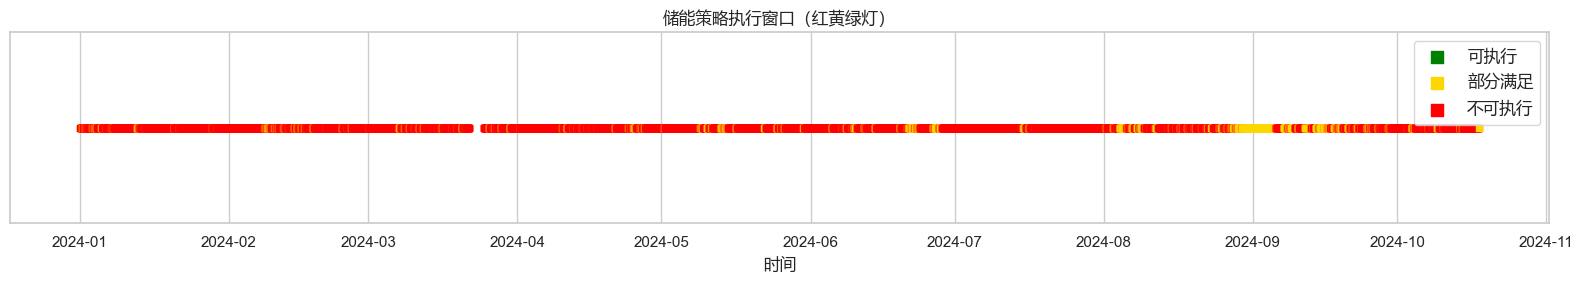

C:\Users\18333\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 31574 (\N{CJK UNIFIED IDEOGRAPH-7B56}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\18333\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 30053 (\N{CJK UNIFIED IDEOGRAPH-7565}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\18333\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 31383 (\N{CJK UNIFIED IDEOGRAPH-7A97}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\18333\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 21475 (\N{CJK UNIFIED IDEOGRAPH-53E3}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\18333\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 31561 (\N{CJK UNIFIED IDEOGRAPH-7B49}) missing from font(s) Arial.
  fig.canvas.draw()


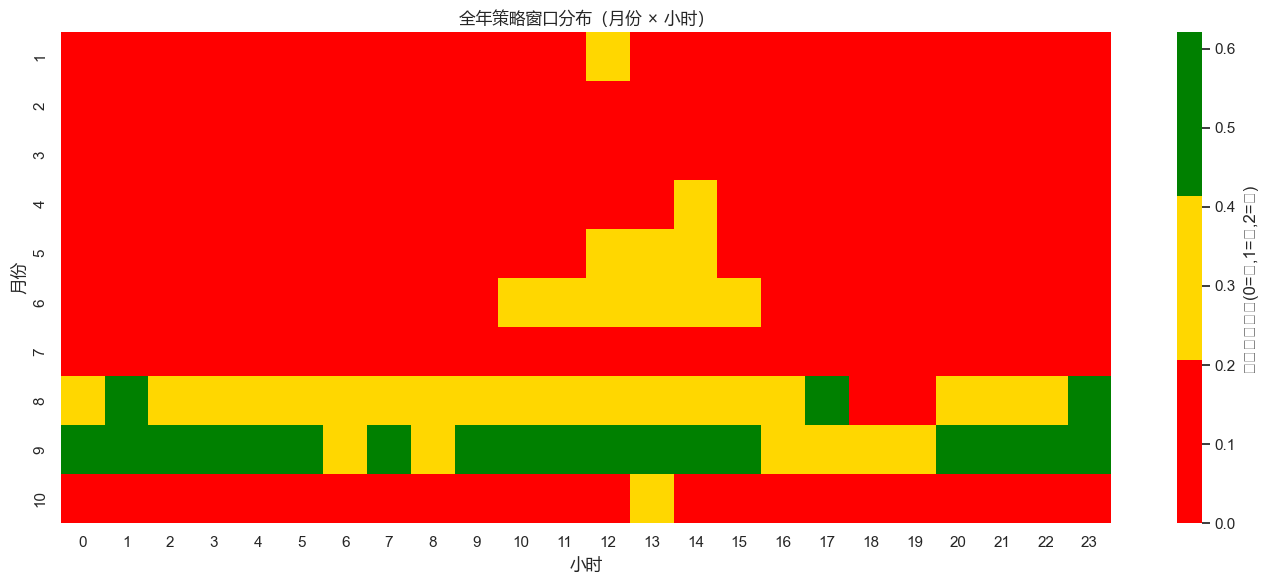

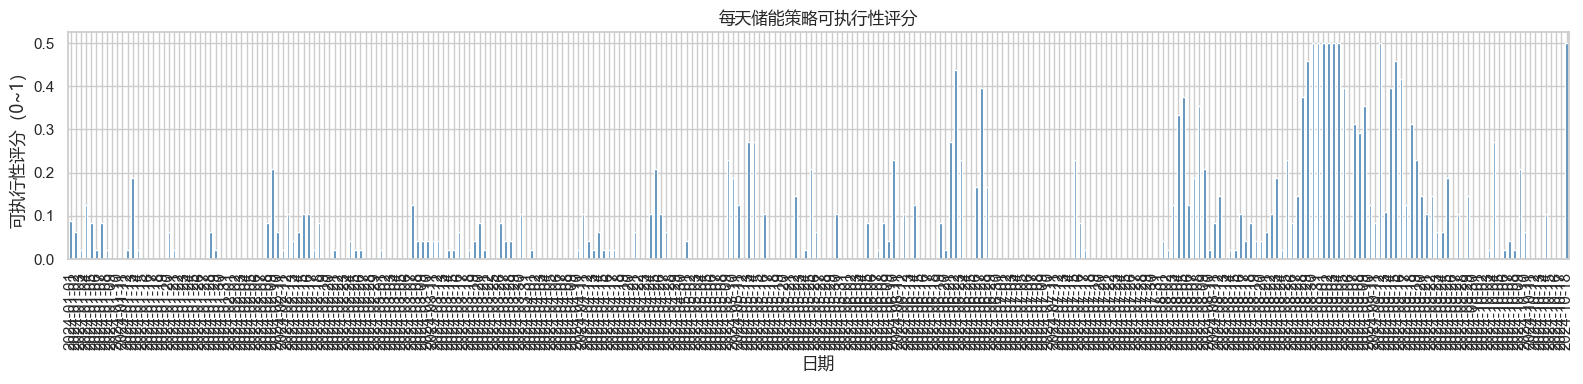

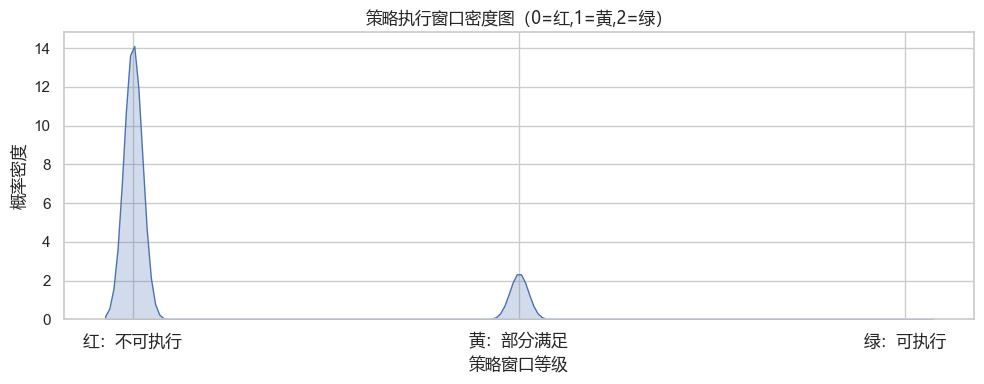

{'推荐类型': '不建议建设储能', '建议功率范围_kW': (0, 0), '建议容量范围_kWh': (0, 0), '策略说明': '电价差不足或可执行窗口过小，难以取得合理收益。'}


In [31]:
analyzer = StorageFeasibilityAnalyzer_V5(
    load_col="负荷",
    price_col="电价",
    time_col="时间",
    transformer_kva=90000,
    power_factor=0.95,
    power_unit="MW",
    price_unit="CNY_per_MWh",
)

# 1）电价与负荷自动对齐（最推荐）
res = analyzer.analyze_combined(df_price, df_load, mode="inner")

# 2）查看综合结果
print(res["匹配性分析"])
print(res["变压器分析"])

# 3）做图
df2 = res["数据"]
analyzer.plot_matching_heatmaps(df2)
analyzer.plot_matching_multidim(df2)

# 4）策略推荐
print(analyzer.recommend_strategy(
    res["电价分析"],
    res["负荷分析"],
    res["变压器分析"],
    res["匹配性分析"]
))
